Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix,classification_report


Load the dataset

In [2]:
df = pd.read_csv("spam.csv",encoding="latin")

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Done basic Data analysis

In [4]:
df.drop(["Unnamed: 2","Unnamed: 3","Unnamed: 4"],axis=1,inplace=True)

In [5]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
df.duplicated().sum()

np.int64(403)

In [7]:
df = df.drop_duplicates(subset=['v1','v2']).reset_index(drop=True)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns = ["labels","text"]

In [10]:
df.shape

(5169, 2)

In [11]:
df.head()

,labels,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Used Labelencoder for the labels column

In [12]:
enc = LabelEncoder()
df["labels"] = enc.fit_transform(df["labels"])

In [13]:
df.head()

,labels,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


Added the new columns as given in the assignment

In [14]:
# message length
df['msg_length'] = df['text'].apply(len)

# count digits
df['digit_count'] = df['text'].apply(lambda x: sum(ch.isdigit() for ch in x))

# count capital letters
df['capital_count'] = df['text'].apply(lambda x: sum(ch.isupper() for ch in x))

In [15]:
df.head()

,labels,text,msg_length,digit_count,capital_count
0,0,"Go until jurong point, crazy.. Available only ...",111,0,3
1,0,Ok lar... Joking wif u oni...,29,0,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,25,10
3,0,U dun say so early hor... U c already then say...,49,0,2
4,0,"Nah I don't think he goes to usf, he lives aro...",61,0,2


Used TF-IDF Vectorizer for vectorization

In [16]:
vectorizer = TfidfVectorizer(stop_words='english',max_features=1000)
X_tfidf = vectorizer.fit_transform(df["text"])

In [17]:
X_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 26777 stored elements and shape (5169, 1000)>

In [18]:
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=vectorizer.get_feature_names_out())

In [19]:
final_df = pd.concat([tfidf_df, df[["msg_length", "digit_count", "capital_count"]]], axis=1)

In [20]:
x= final_df
y = df["labels"]

In [21]:
x.head()

,00,000,02,03,04,06,0800,08000839402,08000930705,08712460324,...,yr,yrs,yup,ì_,ìï,û_,ûò,msg_length,digit_count,capital_count
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,111,0,3
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29,0,2
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,155,25,10
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49,0,2
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,61,0,2


In [22]:
y

0       0
1       0
2       1
3       0
4       0
       ..
5164    1
5165    0
5166    0
5167    0
5168    0
Name: labels, Length: 5169, dtype: int64

Spliting the dataset in the ratio of 60/20/20

In [23]:
x_train,x_temp,y_train,y_temp = train_test_split(x,y,test_size=0.4,random_state=42,stratify=y)
x_val,x_test,y_val,y_test = train_test_split(x_temp,y_temp,test_size=0.5,random_state=42,stratify=y_temp)

Used Smote to avoid class imbalance

In [24]:
smote = SMOTE(random_state=42)
x_train_smote,y_train_smote = smote.fit_resample(x_train,y_train)

In [25]:
print("Original class distribution:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Original class distribution: labels
0    2709
1     392
Name: count, dtype: int64
After SMOTE: labels
0    2709
1    2709
Name: count, dtype: int64


Train the model using linearsvm with different C_values to find the best C 


In [26]:
C_values = [0.01, 0.1, 1, 10, 100]
best_C = None
best_val_score = -1
best_model = None

for Cval in C_values:
    model = LinearSVC(C=Cval,class_weight='balanced')
    model.fit(x_train_smote, y_train_smote)
    val_score = model.score(x_val, y_val)
    print(f"C={Cval} -> Validation Accuracy = {val_score}")
    
    if val_score > best_val_score:
        best_val_score = val_score
        best_C = Cval
        best_model = model

print(f"\nBest C value based on validation set: {best_C}")

C=0.01 -> Validation Accuracy = 0.9709864603481625
C=0.1 -> Validation Accuracy = 0.9854932301740812
C=1 -> Validation Accuracy = 0.9806576402321083
C=10 -> Validation Accuracy = 0.9777562862669246
C=100 -> Validation Accuracy = 0.9787234042553191

Best C value based on validation set: 0.1


In [27]:
y_pred_test = best_model.predict(x_test)

acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test)
rec = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)
cm = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix:\n", cm)
print("SVM Performance on Test Set:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

Confusion Matrix:
 [[900   4]
 [ 10 120]]
SVM Performance on Test Set:
Accuracy:  0.9865
Precision: 0.9677
Recall:    0.9231
F1 Score:  0.9449


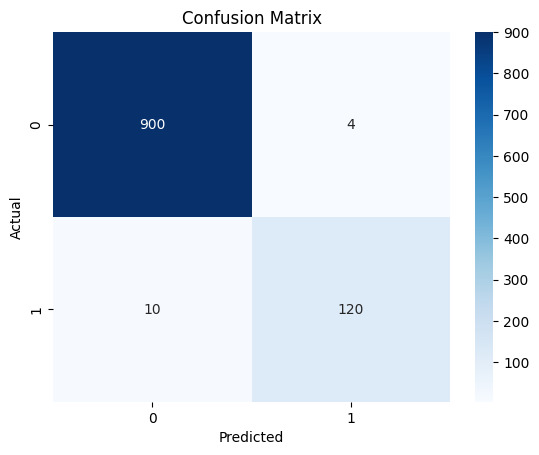

In [28]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [29]:
test_df = pd.DataFrame({
    "text": df.loc[x_test.index, "text"],
    "true": y_test,
    "pred": y_pred_test
})

Printed the 5 false positive and the false negatives

In [30]:
false_positives = test_df[(test_df["true"] == 0) & (test_df["pred"] == 1)].head(5)
false_positives

,text,true,pred
3586,Yep then is fine 7.30 or 8.30 for ice age.,0,1
3268,K.. I yan jiu liao... Sat we can go 4 bugis vi...,0,1
4542,1. Tension face 2. Smiling face 3. Waste face ...,0,1
1059,For me the love should start with attraction.i...,0,1


In [31]:
false_negatives = test_df[(test_df["true"] == 1) & (test_df["pred"] == 0)].head(5)
false_negatives

,text,true,pred
3888,In The Simpsons Movie released in July 2007 na...,1,0
4497,Check Out Choose Your Babe Videos @ sms.shsex....,1,0
4220,Money i have won wining number 946 wot do i do...,1,0
3252,Save money on wedding lingerie at www.bridal.p...,1,0
2302,Babe: U want me dont u baby! Im nasty and have...,1,0


Train the model with rbf 

In [32]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1]
}

rbf_svm = SVC(kernel="rbf")

grid = GridSearchCV(rbf_svm,
                    param_grid,
                    cv=5,
                    scoring='accuracy',
                    n_jobs=-1)

grid.fit(x_train_smote, y_train_smote)


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': [0.001, 0.01, 0.1, 1]},
             scoring='accuracy')

In [33]:
print("Best Parameters:", grid.best_params_)
print("Best Validation Accuracy:", grid.best_score_)

Best Parameters: {'C': 100, 'gamma': 0.01}
Best Validation Accuracy: 0.991879022668343


Printed Classification report

In [34]:
best_model_rbf = grid.best_estimator_
pred_test = best_model_rbf.predict(x_test)

print("Test Accuracy:", accuracy_score(y_test, pred_test))
print(confusion_matrix(y_test, pred_test))
print(classification_report(y_test, pred_test))

Test Accuracy: 0.971953578336557
[[894  10]
 [ 19 111]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       904
           1       0.92      0.85      0.88       130

    accuracy                           0.97      1034
   macro avg       0.95      0.92      0.93      1034
weighted avg       0.97      0.97      0.97      1034



In [35]:
results = pd.DataFrame(grid.cv_results_)
scores = results.pivot_table(values='mean_test_score',
                             index='param_gamma',
                             columns='param_C')

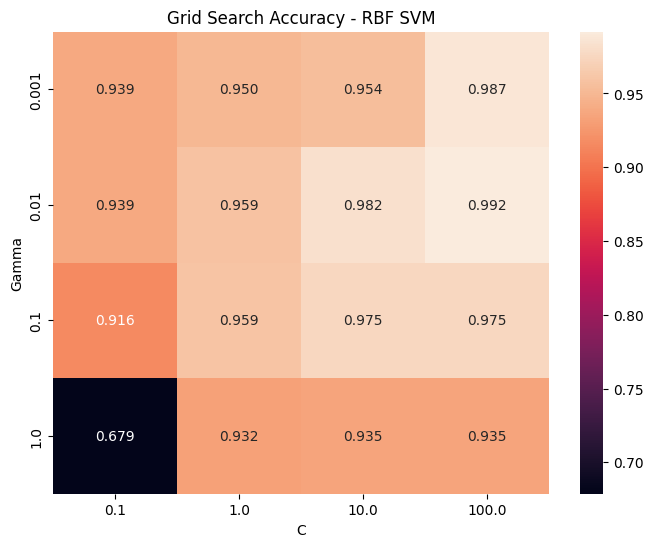

In [36]:
plt.figure(figsize=(8,6))
sns.heatmap(scores, annot=True, fmt=".3f")
plt.title("Grid Search Accuracy - RBF SVM")
plt.xlabel("C")
plt.ylabel("Gamma")
plt.show()

Compared both the models with their accuracy and classification report

In [37]:
y_pred_linear = best_model.predict(x_test)
y_pred_rbf    = best_model_rbf.predict(x_test)

linear_acc=accuracy_score(y_test,y_pred_linear)
rbf_acc = accuracy_score(y_test,y_pred_rbf)

print("accuracy for linear:",linear_acc)
print("accuracy for best rbf:",rbf_acc)

accuracy for linear: 0.9864603481624759
accuracy for best rbf: 0.971953578336557


In [38]:
print("\n--- Linear SVM Report ---\n", classification_report(y_test, y_pred_linear))
print("\n--- RBF SVM Report ---\n", classification_report(y_test, y_pred_rbf))


--- Linear SVM Report ---
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       904
           1       0.97      0.92      0.94       130

    accuracy                           0.99      1034
   macro avg       0.98      0.96      0.97      1034
weighted avg       0.99      0.99      0.99      1034


--- RBF SVM Report ---
               precision    recall  f1-score   support

           0       0.98      0.99      0.98       904
           1       0.92      0.85      0.88       130

    accuracy                           0.97      1034
   macro avg       0.95      0.92      0.93      1034
weighted avg       0.97      0.97      0.97      1034



Plotted ROC and AUC for both the linear and rbf

Linear SVM AUC: 0.9955156569094623
RBF SVM AUC: 0.9900187202178352


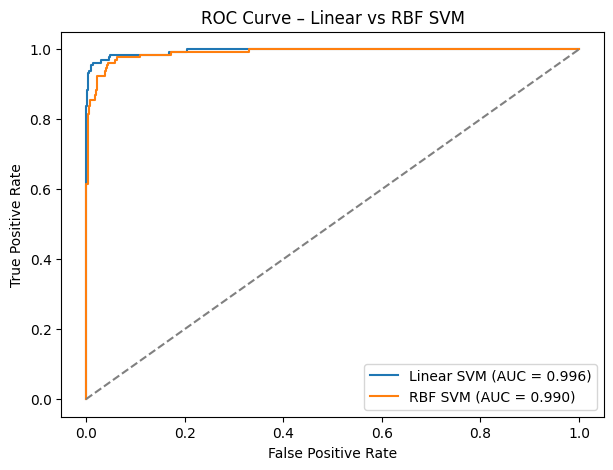

In [39]:
# Decision scores / probabilities
linear_scores = best_model.decision_function(x_test)
rbf_probs     = best_model_rbf.decision_function(x_test)

# Compute ROC
fpr_lin, tpr_lin, _ = roc_curve(y_test, linear_scores)
fpr_rbf, tpr_rbf, _ = roc_curve(y_test, rbf_probs)

# Compute AUC
auc_lin = roc_auc_score(y_test, linear_scores)
auc_rbf = roc_auc_score(y_test, rbf_probs)

print("Linear SVM AUC:", auc_lin)
print("RBF SVM AUC:", auc_rbf)

# Plot ROC curves
plt.figure(figsize=(7,5))
plt.plot(fpr_lin, tpr_lin, label=f'Linear SVM (AUC = {auc_lin:.3f})')
plt.plot(fpr_rbf, tpr_rbf, label=f'RBF SVM (AUC = {auc_rbf:.3f})')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Linear vs RBF SVM")
plt.legend()
plt.show()

Predicted new values by both the models

In [40]:
# Example new messages
new_msgs = [
    "Got free mobiles,with this offer call - 5820970548",
    "Hey, are we still meeting for lunch tomorrow?"
]

# ---- TF-IDF transform ----
new_tfidf = vectorizer.transform(new_msgs).toarray()

# ---- Add same numeric features ----
msg_length = [len(m) for m in new_msgs]
digit_count = [sum(ch.isdigit() for ch in m) for m in new_msgs]
capital_count = [sum(ch.isupper() for ch in m) for m in new_msgs]

numeric_features = np.array([msg_length, digit_count, capital_count]).T

# ---- Combine TF-IDF + numeric features ----
X_new = np.hstack((new_tfidf, numeric_features))

# ---- Predict using your trained model ----
preds = best_model.predict(X_new)   # or model, linear_model, etc.


# ---- Decode results ----
for msg, label in zip(new_msgs, preds):
    print(f"Message: {msg}\nPredicted Class: {'SPAM' if label == 1 else 'HAM'}\n")


Message: Got free mobiles,with this offer call - 5820970548
Predicted Class: SPAM

Message: Hey, are we still meeting for lunch tomorrow?
Predicted Class: HAM



C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(


In [41]:
# Example new messages
new_msgs = [
    "Got free mobiles,with this offer call - 5820970548",
    "Hey, are we still meeting for lunch tomorrow?"
]

# ---- TF-IDF transform ----
new_tfidf = vectorizer.transform(new_msgs).toarray()

# ---- Add same numeric features ----
msg_length = [len(m) for m in new_msgs]
digit_count = [sum(ch.isdigit() for ch in m) for m in new_msgs]
capital_count = [sum(ch.isupper() for ch in m) for m in new_msgs]

numeric_features = np.array([msg_length, digit_count, capital_count]).T

# ---- Combine TF-IDF + numeric features ----
X_new = np.hstack((new_tfidf, numeric_features))

# ---- Predict using your trained model ----
preds = best_model_rbf.predict(X_new)   # or model, linear_model, etc.


# ---- Decode results ----
for msg, label in zip(new_msgs, preds):
    print(f"Message: {msg}\nPredicted Class: {'SPAM' if label == 1 else 'HAM'}\n")

Message: Got free mobiles,with this offer call - 5820970548
Predicted Class: SPAM

Message: Hey, are we still meeting for lunch tomorrow?
Predicted Class: HAM



C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
